<a href="https://colab.research.google.com/github/anyuanay/info213/blob/main/INFO213_Week1_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 213: Data Science Programming 2
___

### Week 1: Machine Learning
___


**Question:**
- What is machine learning?

**Objectives:**
- Define the basic concept about machine learning
- Describe the differences between supervised and unsupervised learning
- Explain features and feature engineering in machine learning
- Explain underfitting and overfitting
- Describe general strategies for dealing with underfitting and overfitting
- Define appropriate metrics for evaluating machine leaning models

## Classification: Predicting discrete labels

We will first take a look at a simple *classification* task, in which you are given a set of labeled points and want to use these to classify some unlabeled points.

Imagine that we have the data shown in this figure:

![](https://i.imgur.com/qsHrcmX.png)

Here we have two-dimensional data: that is, we have two *features* for each point, represented by the *(x,y)* positions of the points on the plane.
In addition, we have one of two *class labels* for each point, here represented by the colors of the points.
From these features and labels, we would like to create a model that will let us decide whether a new point should be labeled "blue" or "red."

There are a number of possible models for such a classification task, but here we will use an extremely simple one. We will make the assumption that the two groups can be separated by drawing a straight line through the plane between them, such that points on each side of the line fall in the same group.

Here the *model* is a quantitative version of the statement "a straight line separates the classes", while the *model parameters* are the particular numbers describing the location and orientation of that line for our data.
The optimal values for these model parameters are learned from the data (this is the "learning" in machine learning), which is often called *training the model*.

The following figure shows a visual representation of what the trained model looks like for this data:

![](https://i.imgur.com/Fxk825G.png)

Now that this model has been trained, it can be generalized to new, unlabeled data.
In other words, we can take a new set of data, draw this model line through it, and assign labels to the new points based on this model.
This stage is usually called *prediction*. See the following figure:

![](https://i.imgur.com/dTzqEL3.png)

This is the basic idea of a classification task in machine learning, where "classification" indicates that the data has discrete class labels.
At first glance this may look fairly trivial: it would be relatively easy to simply look at this data and draw such a discriminatory line to accomplish this classification.
A benefit of the machine learning approach, however, is that it can generalize to much larger datasets in many more dimensions.

For example, this is similar to the task of automated spam detection for email; in this case, we might use the following features and labels:

- *feature 1*, *feature 2*, etc. $\to$ normalized counts of important words or phrases ("Lottery", "Money Prize", etc.)
- *label* $\to$ "spam" or "not spam"

## Clustering: Inferring labels on unlabeled data

One common case of unsupervised learning is "clustering," in which data is automatically assigned to some number of discrete groups.

For example, we might have some two-dimensional data like that shown in the following figure:

![](https://i.imgur.com/niM9YXk.png)

By eye, it is clear that each of these points is part of a distinct group.

Given this input, a clustering model will use the intrinsic structure of the data to determine which points are related.
Using the very fast and intuitive *k*-means algorithm, we find the clusters shown in the following figure:

![](https://i.imgur.com/JSJ7CmE.png)

## Underfitting and Overfitting

A common danger in machine learning is overfitting—producing a model that performs well on the data you train it on but that generalizes poorly to any new data.

The other side of this is underfitting, producing a model that doesn’t perform well
even on the training data, although typically when this happens you decide your
model isn’t good enough and keep looking for a better one.

![](https://i.imgur.com/oDDNc07.png)


The most fundamental approach to dealing with underfitting and overfitting is to use different data to train the
model and to test the model.

## Correctness

Given a set of labeled data and a predictive model, every data point lies in one of four categories:
* True positive (tp): “This message is spam, and we correctly predicted spam.”
* False positive (fp) (Type 1 Error): “This message is not spam, but we predicted spam.”
* False negative (fn) (Type 2 Error): “This message is spam, but we predicted not
spam.”
* True negative (tn): “This message is not spam, and we correctly predicted not spam.”

We often represent these as counts in a confusion matrix:

|      |positive | negative |
|------|------|------|
|positive|tp |fp|
|negative|fn | tn|

$accuracy = \frac{tp + tn}{tp + fp+tn+fn}$

$precision = \frac{tp}{tp+fp}$

$recall = \frac{tp}{tp+fn}$

$F1\_Score = \frac{2}{\frac{1}{recall} + \frac{1}{precision}}$

## The Bias and Variance Trade-Off
- Underfitting models will make a lot of mistakes for pretty much any training set (drawn from the same population),
which means that it has a high bias. Any two randomly chosen
training sets should give pretty similar models (since any two randomly chosen training
sets should have pretty similar average values). So we say that it has a low variance.
- Overfitting models have very low bias but very high variance (since any two training sets would likely give rise to very different models).

Thinking about model problems this way can help you figure out what to do when your
model doesn’t work so well.

- If your model has high bias (which means it performs poorly even on your training
data) then one thing to try is adding more features.
- If your model has high variance, then you can similarly remove features. But another
solution is to obtain more data (if you can).

Holding model complexity constant, the more data you have, the harder it is to overfit.
On the other hand, more data won’t help with bias. If your model doesn’t use enough
features to capture regularities in the data, throwing more data at it won’t help.

## Feature Extraction and Selection

Features are the inputs we provide to our model.

How do we choose features? That’s where a combination of experience and domain
expertise comes into play. The lessons we have learned about data cleaning and wrangling allow us to extract features  based on our needs.

## Introducing Scikit-Learn

There are several Python libraries which provide solid implementations of a range of machine learning algorithms.
One of the best known is [Scikit-Learn](http://scikit-learn.org), a package that provides efficient versions of a large number of common algorithms.

### Feature Matrix
The training data can be thought of as a two-dimensional numerical array or matrix, which we will call the features matrix. By convention, this features matrix is often stored in a variable named X.

The features matrix is assumed to be two-dimensional, with shape [n_samples, n_features], and is most often contained in a NumPy array or a Pandas DataFrame.

In addition to the feature matrix X, we also generally work with a label or target array, which by convention we will usually call y. The target array is usually one dimensional, with length n_samples, and is generally contained in a NumPy array or Pandas Series.

![](https://i.imgur.com/UEtv9Dv.png)

### Basics of the API

Most commonly, the steps in using the Scikit-Learn estimator API are as follows.

1. Choose a class of model by importing the appropriate estimator class from Scikit-Learn.
2. Choose model hyperparameters by instantiating this class with desired values.
3. Arrange data into a features matrix and target vector following the discussion above.
4. Fit the model to your data by calling the ``fit()`` method of the model instance.
5. Apply the Model to new data:
   - For supervised learning, often we predict labels for unknown data using the ``predict()`` method.
   - For unsupervised learning, we often transform or infer properties of the data using the ``transform()`` or ``predict()`` method.

## Supervised learning example: Simple linear regression

As an example of this process, let's consider a simple linear regression—that is, the common case of fitting a line to $(x, y)$ data.
We will use the following simple data for our regression example:

```
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

rng = np.random.RandomState(42)
x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
plt.scatter(x, y);
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np

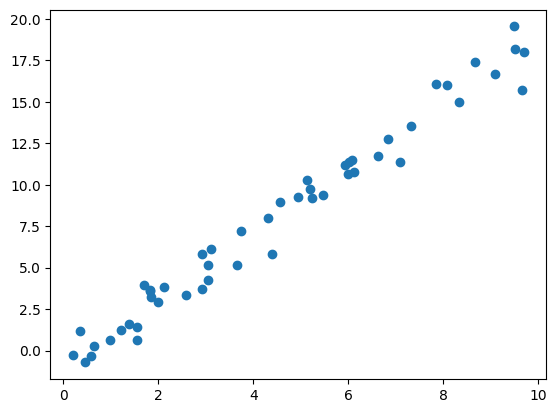

In [2]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(50)
y = 2 * x - 1 + rng.randn(50)
plt.scatter(x, y)

With this data in place, we can use the recipe outlined earlier. Let's walk through the process:

### 1. Choose a class of model

In Scikit-Learn, every class of model is represented by a Python class.
So, for example, if we would like to compute a simple linear regression model, we can import the linear regression class:

```
from sklearn.linear_model import LinearRegression
```

In [3]:
from sklearn.linear_model import LinearRegression

### 2. Choose model hyperparameters

An important point is that *a class of model is not the same as an instance of a model*.

Once we have decided on our model class, there are still some options open to us.
Depending on the model class we are working with, we might need to answer one or more questions like the following:

- Would we like to fit for the offset (i.e., *y*-intercept)?
- Would we like the model to be normalized?
- Would we like to preprocess our features to add model flexibility?
- What degree of regularization would we like to use in our model?
- How many model components would we like to use?

These are examples of the important choices that must be made *once the model class is selected*.
These choices are often represented as *hyperparameters*, or parameters that must be set before the model is fit to data.
In Scikit-Learn, hyperparameters are chosen by passing values at model instantiation.


For our linear regression example, we can instantiate the ``LinearRegression`` class and specify that we would like to fit the intercept using the ``fit_intercept`` hyperparameter:

```
model = LinearRegression(fit_intercept=True)
model
```

In [4]:
model = LinearRegression(fit_intercept =  True)

### 3. Arrange data into a features matrix and target vector

Here our target variable ``y`` is already in the correct form (a length-``n_samples`` array), but we need to massage the data ``x`` to make it a matrix of size ``[n_samples, n_features]``.
In this case, this amounts to a simple reshaping of the one-dimensional array:

```
X = x[:, np.newaxis]
X.shape
```

In [5]:
X = x[:, np.newaxis]
X.shape

(50, 1)

### 4. Fit the model to your data

Now it is time to apply our model to data.
This can be done with the ``fit()`` method of the model:

```
model.fit(X, y)
```

In [6]:
model.fit(X, y)

LinearRegression()

This ``fit()`` command causes a number of model-dependent internal computations to take place, and the results of these computations are stored in model-specific attributes that the user can explore.
In Scikit-Learn, by convention all model parameters that were learned during the ``fit()`` process have trailing underscores; for example in this linear model, we have the following:

```
model.coef_
```

In [7]:
model.coef_

array([1.9776566])

```
model.intercept_
```

In [8]:
model.intercept_

-0.9033107255311146

These two parameters represent the slope and intercept of the simple linear fit to the data.
Comparing to the data definition, we see that they are very close to the input slope of 2 and intercept of -1.

### 5. Predict labels for unknown data

Once the model is trained, the main task of supervised machine learning is to evaluate it based on what it says about new data that was not part of the training set.
In Scikit-Learn, this can be done using the ``predict()`` method.
For the sake of this example, our "new data" will be a grid of *x* values, and we will ask what *y* values the model predicts:

```
xfit = np.linspace(-1, 11)
```

In [9]:
xfit = np.linspace(-1, 11)

As before, we need to coerce these *x* values into a ``[n_samples, n_features]`` features matrix, after which we can feed it to the model:

```
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)
```

In [10]:
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)

Finally, let's visualize the results by plotting first the raw data, and then this model fit:

```
plt.scatter(x, y)
plt.plot(xfit, yfit);
```

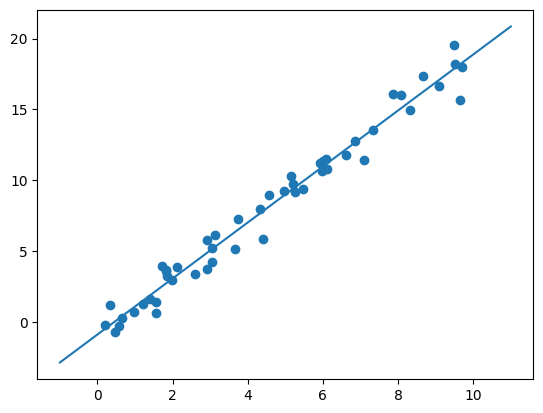

In [11]:
plt.scatter(x, y)
plt.plot(xfit, yfit);